In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

data=pd.read_csv('housing_price_data.csv')
X=data['Size'].values
Y=data['Price'].values

X=X.reshape(len(X),1)
Y=Y.reshape(len(Y),1)

plt.xlabel('Size')
plt.ylabel('Price')
plt.plot(X,Y,'ro')
plt.show()
print(X.shape)
print(Y.shape)

ModuleNotFoundError: No module named 'pandas'

In [86]:
#Normalize X
max_min=X.max(0)-X.min(0)
Xmin = X.min(0)
X=(X-Xmin)/(max_min)
print(X.shape)

#Adding bias
X_ones=np.ones((len(X),1))
X=np.concatenate((X_ones,X),axis=1)
Y=Y.reshape(-1,1)
print(X.shape)
print(Y.shape)
X_sort=np.sort(X,axis=0)

x_train=X[:,1]
y_train=Y

#Learning rate
np.random.seed(20)
w=np.random.rand(2,1);
w0=w[0]
w1=w[1]
nu=0.3
max_epochs=2000
m=len(x_train)
mse=[]
for epoch in range(max_epochs):
    y_pred= w0+w1*x_train
    error=y_pred.reshape(-1,1) -y_train
    mse_arr= (1/m)*np.sum(error ** 2)
    mse.append(mse_arr)

    dw0=(2/m)*np.sum(error)
    dw1=(2/m)*np.sum(error * x_train.reshape(-1,1))

    w0-=nu *dw0
    w1-=nu*dw1

w[0]=w0
w[1]=w1


(781, 1)
(781, 2)
(781, 1)


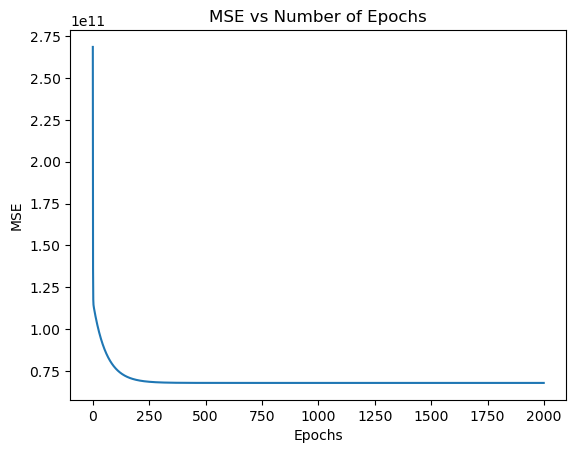

In [87]:
plt.title('MSE vs Number of Epochs')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.plot(range(max_epochs),mse)
plt.show()

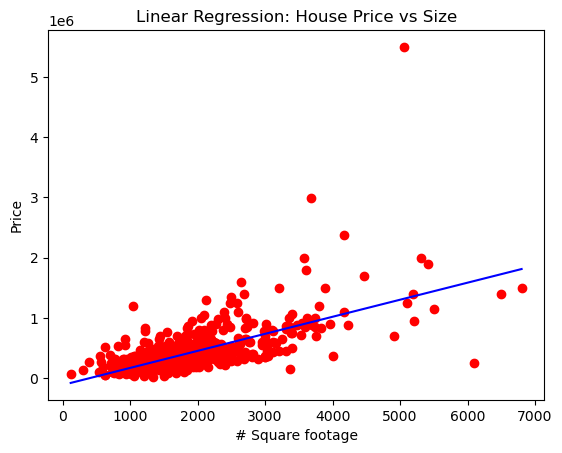

In [88]:
yhat=w0+w1*X_sort
plt.plot(X[:,1]*min_max+Xmin ,Y,'ro')
plt.plot(X_sort*min_max+Xmin,yhat,'b',label='Gradient Descent')
plt.xlabel("# Square footage")
plt.ylabel("Price")
plt.title("Linear Regression: House Price vs Size")
plt.show()

In [92]:
house_size=5000
house_normalized=(house_size-Xmin)/(min_max)
x_5000=np.array([[1,house_normalized[0]]])
predicted_price=x_5000 @w

print(f"Predicted price for a 5000 sq ft house: ${predicted_price[0, 0]:,.2f}")


Predicted price for a 5000 sq ft house: $1,301,938.04
